# TASK I — Support Vector Machine (SVM)

## TASK I1 — SVM Basics

### Objective

To understand and implement Support Vector Machine (SVM) for binary classification using the Diabetes dataset.

### Tasks Covered

- Load and explore the dataset
- Identify features (X) and target (y)
- Handle missing values
- Perform feature scaling using StandardScaler
- Split the dataset into training and testing sets
- Train a Linear SVM using SVC(kernel="linear")
- Understand hyperplane and margin
- Understand hard margin and soft margin
- Understand support vectors
- Understand the importance of feature scaling


In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

print("Libraries imported successfully!")


Libraries imported successfully!


In [10]:
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv("../../diabetes.csv", header=None, names=columns)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.head()

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [11]:
print("Dataset columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset shape:
(768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
6        0
148      0
72       0
35       0
0        0
33.6     0
0.627    0
50       0
1        0
dtype: int64


In [12]:
print("Dataset columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset shape:
(768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [8]:
print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['6', '148', '72', '35', '0', '33.6', '0.627', '50', '1']


In [14]:
columns_with_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns_with_missing] = df[columns_with_missing].replace(0, np.nan)

df[columns_with_missing] = df[columns_with_missing].fillna(
    df[columns_with_missing].median()
)

print("Missing values handled successfully!")
print(df.isnull().sum())

Missing values handled successfully!
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [15]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (614, 8)
Testing shape: (154, 8)


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [18]:
svm_linear = SVC(kernel="linear")

svm_linear.fit(X_train_scaled, y_train)

print("Linear SVM trained successfully!")

Linear SVM trained successfully!


In [19]:
y_pred = svm_linear.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[1 0 0 0 0 0 0 1 0 1]


# Train SVM models with different kernels

svm_linear = SVC(kernel="linear")
svm_poly = SVC(kernel="poly", degree=3)
svm_rbf = SVC(kernel="rbf")

svm_linear.fit(X_train_scaled, y_train)
svm_poly.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

print("All SVM kernel models trained successfully!")

In [21]:
# Train SVM models with different kernels

svm_linear = SVC(kernel="linear")
svm_poly = SVC(kernel="poly", degree=3)
svm_rbf = SVC(kernel="rbf")

svm_linear.fit(X_train_scaled, y_train)
svm_poly.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

print("All SVM kernel models trained successfully!")

All SVM kernel models trained successfully!


In [22]:
from sklearn.metrics import accuracy_score

# Predictions
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_poly = svm_poly.predict(X_test_scaled)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

# Calculate accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

# Create comparison table
kernel_results = pd.DataFrame({
    "Kernel": ["Linear", "Polynomial", "RBF"],
    "Accuracy": [
        accuracy_linear,
        accuracy_poly,
        accuracy_rbf
    ]
})

kernel_results

,Kernel,Accuracy
0,Linear,0.701299
1,Polynomial,0.714286
2,RBF,0.740260


In [23]:
from sklearn.metrics import classification_report

# Generate predictions using the best-performing RBF SVM
y_pred_best = svm_rbf.predict(X_test_scaled)

print("Classification Report - RBF SVM")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_best,
    target_names=["No Diabetes", "Diabetes"]
))

Classification Report - RBF SVM
              precision    recall  f1-score   support

 No Diabetes       0.78      0.84      0.81       100
    Diabetes       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



Confusion Matrix:
[[84 16]
 [24 30]]


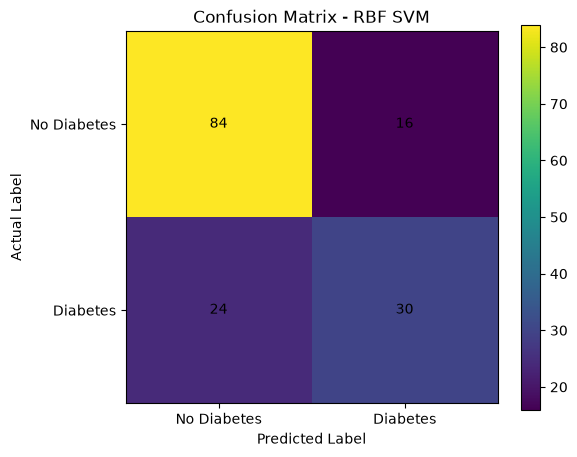

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix using matplotlib
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - RBF SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add labels
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.yticks([0, 1], ["No Diabetes", "Diabetes"])

# Display values inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print("RBF SVM Evaluation Metrics")
print("=" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

RBF SVM Evaluation Metrics
Accuracy  : 0.7403
Precision : 0.6522
Recall    : 0.5556
F1-Score  : 0.6000


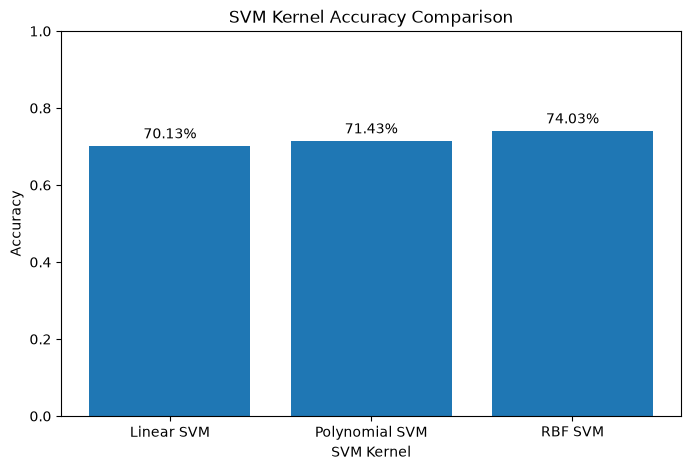

In [27]:
import matplotlib.pyplot as plt

models = ['Linear SVM', 'Polynomial SVM', 'RBF SVM']
accuracies = [
    accuracy_linear,
    accuracy_poly,
    accuracy_rbf
]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies)

plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xlabel('SVM Kernel')
plt.title('SVM Kernel Accuracy Comparison')

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        acc + 0.02,
        f'{acc:.2%}',
        ha='center'
    )

plt.show()

Confusion Matrix:
[[84 16]
 [24 30]]


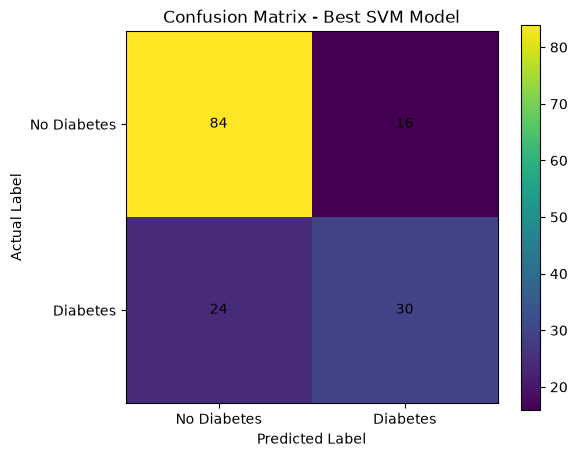

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.yticks([0, 1], ["No Diabetes", "Diabetes"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Best SVM Model")

# Display values inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

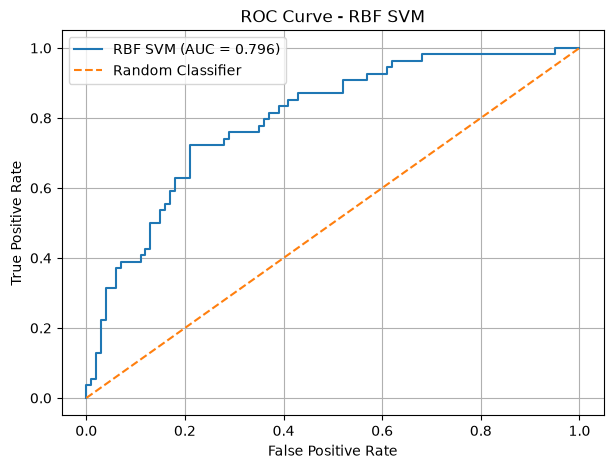

ROC-AUC Score: 0.7963


In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities/scores from the RBF SVM
y_score = svm_rbf.decision_function(X_test_scaled)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_score)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"RBF SVM (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RBF SVM")
plt.legend()
plt.grid(True)

plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

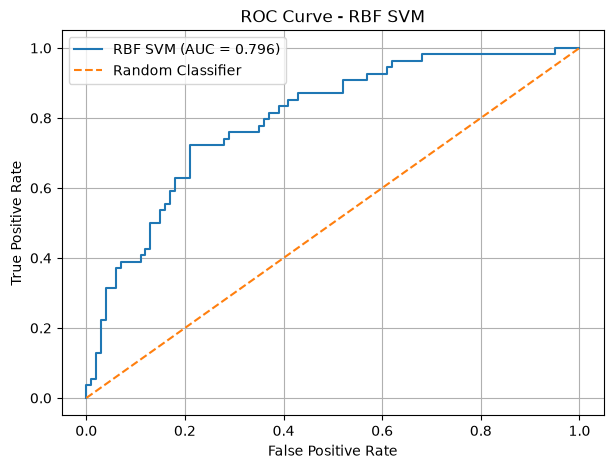

ROC-AUC Score: 0.7963


In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get decision scores from the RBF SVM
y_score = svm_rbf.decision_function(X_test_scaled)

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# AUC
auc_score = roc_auc_score(y_test, y_score)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"RBF SVM (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RBF SVM")
plt.legend()
plt.grid(True)

plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate final metrics
final_accuracy = accuracy_score(y_test, y_pred_best)
final_precision = precision_score(y_test, y_pred_best)
final_recall = recall_score(y_test, y_pred_best)
final_f1 = f1_score(y_test, y_pred_best)

print("=" * 45)
print("FINAL RBF SVM EVALUATION")
print("=" * 45)

print(f"Accuracy  : {final_accuracy:.4f} ({final_accuracy:.2%})")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1-Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {auc_score:.4f}")

print("=" * 45)

FINAL RBF SVM EVALUATION
Accuracy  : 0.7403 (74.03%)
Precision : 0.6522
Recall    : 0.5556
F1-Score  : 0.6000
ROC-AUC   : 0.7963


In [32]:
final_results = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "Polynomial SVM",
        "RBF SVM"
    ],
    "Accuracy": [
        accuracy_linear,
        accuracy_poly,
        accuracy_rbf
    ]
})

final_results["Accuracy (%)"] = final_results["Accuracy"] * 100

final_results

,Model,Accuracy,Accuracy (%)
0,Linear SVM,0.701299,70.129870
1,Polynomial SVM,0.714286,71.428571
2,RBF SVM,0.740260,74.025974


In [33]:
best_index = final_results["Accuracy"].idxmax()

best_model_name = final_results.loc[best_index, "Model"]
best_accuracy = final_results.loc[best_index, "Accuracy"]

print("Best SVM Model:", best_model_name)
print(f"Best Accuracy: {best_accuracy:.2%}")

Best SVM Model: RBF SVM
Best Accuracy: 74.03%


In [35]:
import joblib
import os

# Path to the main model folder
model_dir = "../../model"

# Create folder if it doesn't exist
os.makedirs(model_dir, exist_ok=True)

# Save the trained RBF SVM model
model_path = os.path.join(model_dir, "svm_rbf_model.pkl")

joblib.dump(svm_rbf, model_path)

print("RBF SVM model saved successfully!")
print("Saved at:", model_path)

RBF SVM model saved successfully!
Saved at: ../../model/svm_rbf_model.pkl


In [36]:
scaler_path = os.path.join(model_dir, "scaler.pkl")

joblib.dump(scaler, scaler_path)

print("Scaler saved successfully!")
print("Saved at:", scaler_path)

Scaler saved successfully!
Saved at: ../../model/scaler.pkl


In [37]:
import os

print("Model exists:", os.path.exists("../../model/svm_rbf_model.pkl"))
print("Scaler exists:", os.path.exists("../../model/scaler.pkl"))

Model exists: True
Scaler exists: True


In [38]:
from sklearn.metrics import classification_report

print("Classification Report - RBF SVM")
print("=" * 45)

print(classification_report(
    y_test,
    y_pred_best,
    target_names=["No Diabetes", "Diabetes"]
))

Classification Report - RBF SVM
              precision    recall  f1-score   support

 No Diabetes       0.78      0.84      0.81       100
    Diabetes       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_accuracy = accuracy_score(y_test, y_pred_best)
final_precision = precision_score(y_test, y_pred_best)
final_recall = recall_score(y_test, y_pred_best)
final_f1 = f1_score(y_test, y_pred_best)

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

final_results["Percentage"] = final_results["Score"] * 100

final_results

,Metric,Score,Percentage
0,Accuracy,0.740260,74.025974
1,Precision,0.652174,65.217391
2,Recall,0.555556,55.555556
3,F1-Score,0.600000,60.000000


In [40]:
print("FINAL SVM MODEL SUMMARY")
print("=" * 50)
print(f"Best Kernel     : RBF")
print(f"Accuracy        : {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"Precision       : {final_precision:.4f} ({final_precision*100:.2f}%)")
print(f"Recall          : {final_recall:.4f} ({final_recall*100:.2f}%)")
print(f"F1-Score        : {final_f1:.4f} ({final_f1*100:.2f}%)")
print("=" * 50)
print("Model and scaler saved successfully.")

FINAL SVM MODEL SUMMARY
Best Kernel     : RBF
Accuracy        : 0.7403 (74.03%)
Precision       : 0.6522 (65.22%)
Recall          : 0.5556 (55.56%)
F1-Score        : 0.6000 (60.00%)
Model and scaler saved successfully.


In [41]:
import joblib

# Load saved model and scaler
loaded_model = joblib.load("../../model/svm_rbf_model.pkl")
loaded_scaler = joblib.load("../../model/scaler.pkl")

# Transform test data using saved scaler
X_test_loaded = loaded_scaler.transform(X_test)

# Make predictions
loaded_predictions = loaded_model.predict(X_test_loaded)

# Check accuracy
loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("Saved Model Verification")
print("=" * 40)
print(f"Loaded Model Accuracy: {loaded_accuracy:.4f}")
print(f"Original Accuracy    : {final_accuracy:.4f}")

if abs(loaded_accuracy - final_accuracy) < 0.0001:
    print("✅ Saved model verified successfully!")
else:
    print("⚠️ Accuracy mismatch detected.")

Saved Model Verification
Loaded Model Accuracy: 0.7403
Original Accuracy    : 0.7403
✅ Saved model verified successfully!


import joblib

# Load saved model and scaler
loaded_model = joblib.load("../../model/svm_rbf_model.pkl")
loaded_scaler = joblib.load("../../model/scaler.pkl")

# Transform test data using saved scaler
X_test_loaded = loaded_scaler.transform(X_test)

# Make predictions
loaded_predictions = loaded_model.predict(X_test_loaded)

# Check accuracy
loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("Saved Model Verification")
print("=" * 40)
print(f"Loaded Model Accuracy: {loaded_accuracy:.4f}")
print(f"Original Accuracy    : {final_accuracy:.4f}")

if abs(loaded_accuracy - final_accuracy) < 0.0001:
    print("✅ Saved model verified successfully!")
else:
    print("⚠️ Accuracy mismatch detected.")

In [42]:
from sklearn.metrics import roc_auc_score

# Get decision scores from the best RBF SVM
y_scores = svm_rbf.decision_function(X_test_scaled)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_scores)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.7963


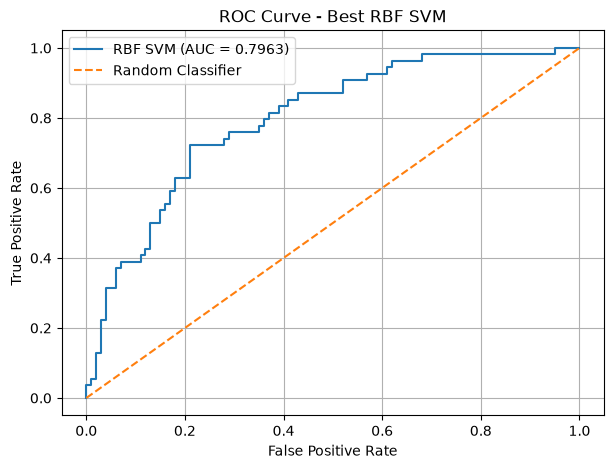

In [43]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Calculate AUC
roc_auc_value = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"RBF SVM (AUC = {roc_auc_value:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best RBF SVM")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# Get decision function scores from the best RBF SVM
y_scores = svm_rbf.decision_function(X_test_scaled)

print("First 10 Decision Scores:")
print(y_scores[:10])

First 10 Decision Scores:
[ 0.56215684 -1.11377006 -0.94763213 -0.33318046 -1.29447036 -0.66156413
 -0.27079555  1.03924159 -1.63221638  1.1531573 ]


In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define different decision thresholds
thresholds = [-0.5, 0, 0.5]

results = []

for threshold in thresholds:
    # Convert decision scores into predictions
    y_pred_threshold = (y_scores >= threshold).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    
    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1-Score
0,-0.5,0.733766,0.600000,0.722222,0.655462
1,0.0,0.740260,0.652174,0.555556,0.600000
2,0.5,0.727273,0.700000,0.388889,0.500000


In [46]:
print("Threshold Analysis - RBF SVM")
print("=" * 50)

display(
    threshold_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

Threshold Analysis - RBF SVM


,Threshold,Accuracy,Precision,Recall,F1-Score
0,-0.500000,0.7338,0.6000,0.7222,0.6555
1,0.000000,0.7403,0.6522,0.5556,0.6000
2,0.500000,0.7273,0.7000,0.3889,0.5000


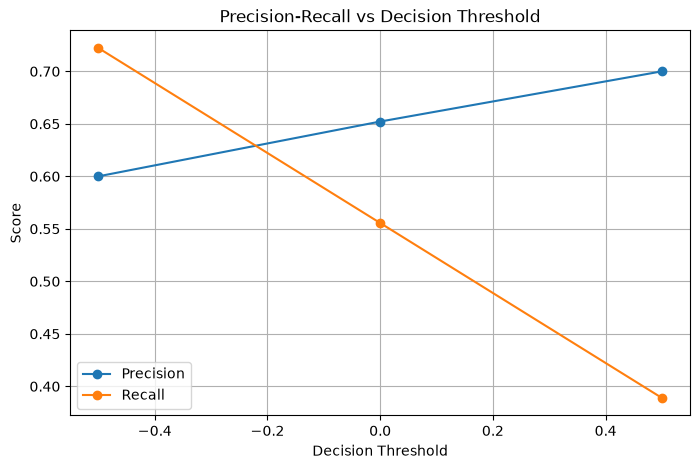

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# Default SVM predictions
y_pred_default = svm_rbf.predict(X_test_scaled)

# Prediction using default threshold = 0
y_pred_threshold_0 = (y_scores >= 0).astype(int)

print("Default predict() vs decision_function threshold = 0")
print("=" * 55)

print(
    "Predictions are identical:",
    np.array_equal(y_pred_default, y_pred_threshold_0)
)

Default predict() vs decision_function threshold = 0
Predictions are identical: True


## Decision Function and Threshold Analysis

The `decision_function()` of an SVM returns a continuous decision score for each sample. 
The sign of this score determines the predicted class.

- A score greater than or equal to 0 is classified as class 1 (Diabetes).
- A score less than 0 is classified as class 0 (No Diabetes).

The `predict()` method automatically applies the default decision threshold of 0.

By changing the decision threshold, the classification behavior of the model can be adjusted.

### Effect of Threshold

A lower threshold makes it easier for a sample to be classified as positive. 
This generally increases Recall but may reduce Precision.

A higher threshold makes the model more conservative when predicting the positive class. 
This can increase Precision but may reduce Recall.

Therefore, the decision threshold creates a trade-off between Precision and Recall.

### Decision Function vs Predict

`decision_function()` returns continuous decision scores, while `predict()` 
returns the final class labels.

For SVM:

- `decision_function()` → confidence-like decision score
- `predict()` → final class prediction

Threshold analysis is useful when the cost of false positives and false negatives 
is different. In medical applications such as diabetes prediction, Recall can be 
particularly important because missing a diabetic patient may have serious consequences.